In [1]:
# Libraries install 
!pip install pandas numpy scikit-learn matplotlib seaborn flask

In [3]:
# Database Data Load 
import sqlite3
import pandas as pd

# Database connection
conn = sqlite3.connect(r'C:\Users\priya\Insurance premium prediction\Regression.db')

# Insurance_Prediction table data
query = "SELECT * FROM Insurance_Prediction"
df = pd.read_sql_query(query, conn)

# Connection close
conn.close()

# Data 
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Data save CSV 
df.to_csv('insurance_data.csv', index=False)
print("\nData saved as 'insurance_data.csv'")

Dataset Shape: (1000000, 12)

First 5 rows:
    age  gender    bmi  children smoker     region medical_history  \
0  46.0    male  21.45       5.0    yes  southeast        Diabetes   
1  25.0  female  25.38       2.0    yes  northwest        Diabetes   
2  38.0    male  44.88       2.0    yes  southwest            None   
3  25.0    male  19.89       0.0     no  northwest            None   
4  49.0    male  38.21       3.0    yes  northwest        Diabetes   

  family_medical_history exercise_frequency    occupation coverage_level  \
0                   None              Never   Blue collar        Premium   
1    High blood pressure       Occasionally  White collar        Premium   
2    High blood pressure       Occasionally   Blue collar        Premium   
3               Diabetes             Rarely  White collar       Standard   
4    High blood pressure             Rarely  White collar       Standard   

        charges  
0  20460.307669  
1  20390.899218  
2  20204.476302  
3  117

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   age                     960000 non-null   float64
 1   gender                  976000 non-null   object 
 2   bmi                     1000000 non-null  float64
 3   children                968000 non-null   float64
 4   smoker                  1000000 non-null  object 
 5   region                  1000000 non-null  object 
 6   medical_history         749238 non-null   object 
 7   family_medical_history  749596 non-null   object 
 8   exercise_frequency      1000000 non-null  object 
 9   occupation              968000 non-null   object 
 10  coverage_level          1000000 non-null  object 
 11  charges                 1000000 non-null  float64
dtypes: float64(4), object(8)
memory usage: 91.6+ MB
None


Statistical Summary:
                 age   

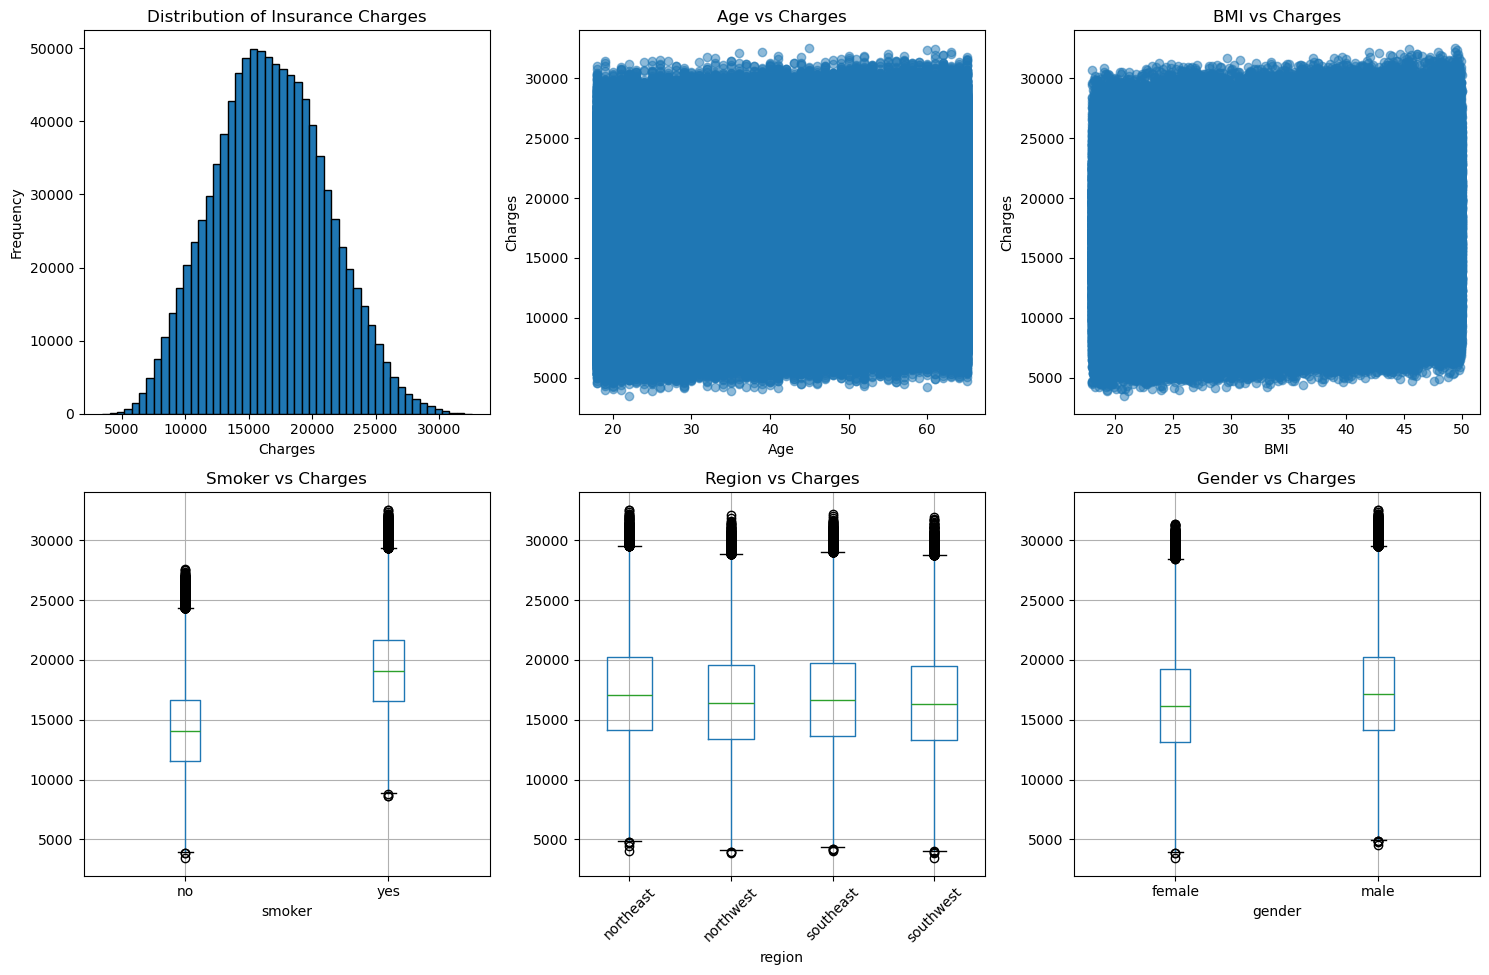


Visualization saved as 'data_exploration.png'


In [4]:
# Data Exploration and Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data load 
df = pd.read_csv('insurance_data.csv')

# Basic Information
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())
print("\n" + "="*50)

# Missing Values तपासा
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "="*50)

# Unique values each column
print("\nUnique Values in Each Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Visualization
plt.figure(figsize=(15, 10))

# 1. Charges Distribution
plt.subplot(2, 3, 1)
plt.hist(df['charges'], bins=50, edgecolor='black')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')

# 2. Age vs Charges
plt.subplot(2, 3, 2)
plt.scatter(df['age'], df['charges'], alpha=0.5)
plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')

# 3. BMI vs Charges
plt.subplot(2, 3, 3)
plt.scatter(df['bmi'], df['charges'], alpha=0.5)
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')

# 4. Smoker vs Charges
plt.subplot(2, 3, 4)
df.boxplot(column='charges', by='smoker', ax=plt.gca())
plt.title('Smoker vs Charges')
plt.suptitle('')

# 5. Region vs Charges
plt.subplot(2, 3, 5)
df.boxplot(column='charges', by='region', ax=plt.gca())
plt.title('Region vs Charges')
plt.suptitle('')
plt.xticks(rotation=45)

# 6. Gender vs Charges
plt.subplot(2, 3, 6)
df.boxplot(column='charges', by='gender', ax=plt.gca())
plt.title('Gender vs Charges')
plt.suptitle('')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'data_exploration.png'")

In [6]:
# Data Preprocessing and Feature Engineering 
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

# Data load 
df = pd.read_csv('insurance_data.csv')

print(f"Original Dataset Shape: {df.shape}")

#  DATA CLEANING 

# Missing values handle 
print(f"\nMissing values before cleaning:\n{df.isnull().sum()}")

# Create a copy to avoid SettingWithCopyWarning
df = df.copy()

# Numerical columns median fill 
numerical_cols = ['age', 'bmi', 'children']
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Categorical columns mode fill 
categorical_cols = ['gender', 'smoker', 'region', 'medical_history', 
                    'family_medical_history', 'exercise_frequency', 
                    'occupation', 'coverage_level']
for col in categorical_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nMissing values after cleaning:\n{df.isnull().sum()}")

# FEATURE ENGINEERING

# 1. Age Groups 
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100], 
                         labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# 2. BMI Categories
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# 3. High Risk Flag (Smoker + Obese)
df['high_risk'] = ((df['smoker'] == 'yes') & (df['bmi'] > 30)).astype(int)

# 4. Family Size
df['family_size'] = df['children'] + 1

# ENCODING 

# Label Encoders and  save 
label_encoders = {}
categorical_features = ['gender', 'smoker', 'region', 'medical_history',
                       'family_medical_history', 'exercise_frequency',
                       'occupation', 'coverage_level', 'age_group', 'bmi_category']

for col in categorical_features:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Label encoders save 
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("\nLabel Encoders saved!")

#  FEATURE SELECTION 

# Model features select 
feature_columns = [
    'age', 'bmi', 'children', 'family_size', 'high_risk',
    'gender_encoded', 'smoker_encoded', 'region_encoded',
    'medical_history_encoded', 'family_medical_history_encoded',
    'exercise_frequency_encoded', 'occupation_encoded',
    'coverage_level_encoded', 'age_group_encoded', 'bmi_category_encoded'
]

# TRAIN-TEST-LIVE SPLIT

# Problem statement split 
# First 700k for training, next 200k for testing, rest for live data
train_data = df.iloc[:700000].copy()
test_data = df.iloc[700000:900000].copy()
live_data = df.iloc[900000:].copy()

print(f"\n{'='*60}")
print("Data Split:")
print(f"Training Data: {train_data.shape}")
print(f"Testing Data: {test_data.shape}")
print(f"Live Data: {live_data.shape}")
print(f"{'='*60}")

# SCALING 

# Initialize scaler
scaler = StandardScaler()
numerical_features = ['age', 'bmi', 'children', 'family_size']

# Training data - fit and transform
X_train = train_data[feature_columns].copy()
y_train = train_data['charges'].copy()

X_train_scaled = X_train.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Testing data - only transform
X_test = test_data[feature_columns].copy()
y_test = test_data['charges'].copy()

X_test_scaled = X_test.copy()
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

# Scaler save
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler saved!")

# Save processed data
X_train_scaled.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test_scaled.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
live_data.to_csv('live_data.csv', index=False)

print(f"\n{'='*60}")
print(f"Final Training Data: {X_train_scaled.shape}")
print(f"Final Testing Data: {X_test_scaled.shape}")
print(f"Final Live Data: {live_data.shape}")
print(f"{'='*60}")

print("\nFeatures used in model:")
for i, col in enumerate(feature_columns, 1):
    print(f"{i}. {col}")

print("\n✓ Processed data saved successfully!")
print("\nFiles created:")
print("  - X_train.csv")
print("  - y_train.csv")
print("  - X_test.csv")
print("  - y_test.csv")
print("  - live_data.csv")
print("  - label_encoders.pkl")
print("  - scaler.pkl")

Original Dataset Shape: (1000000, 12)

Missing values before cleaning:
age                        40000
gender                     24000
bmi                            0
children                   32000
smoker                         0
region                         0
medical_history           250762
family_medical_history    250404
exercise_frequency             0
occupation                 32000
coverage_level                 0
charges                        0
dtype: int64

Missing values after cleaning:
age                       0
gender                    0
bmi                       0
children                  0
smoker                    0
region                    0
medical_history           0
family_medical_history    0
exercise_frequency        0
occupation                0
coverage_level            0
charges                   0
dtype: int64

Label Encoders saved!

Data Split:
Training Data: (700000, 26)
Testing Data: (200000, 26)
Live Data: (100000, 26)
Scaler saved!

Final Tra

Training Data Shape: (700000, 15)
Target Shape: (700000,)

TRAINING MULTIPLE MODELS...

Training Linear Regression...
  MSE: 11,466,532.73
  RMSE: 3,386.23
  MAE: 2,758.70
  R² Score: 0.4125

Training Ridge Regression...
  MSE: 11,466,532.73
  RMSE: 3,386.23
  MAE: 2,758.70
  R² Score: 0.4125

Training Lasso Regression...
  MSE: 11,466,556.61
  RMSE: 3,386.23
  MAE: 2,758.69
  R² Score: 0.4125

Training Decision Tree...
  MSE: 6,877,925.11
  RMSE: 2,622.58
  MAE: 2,123.91
  R² Score: 0.6476

Training Random Forest...
  MSE: 5,620,249.87
  RMSE: 2,370.71
  MAE: 1,862.06
  R² Score: 0.7120

Training Gradient Boosting...
  MSE: 6,417,386.19
  RMSE: 2,533.26
  MAE: 1,996.09
  R² Score: 0.6712

MODEL COMPARISON
            Model        RMSE         MAE       R2
    Random Forest 2370.706619 1862.063341 0.712017
Gradient Boosting 2533.256046 1996.089731 0.671171
    Decision Tree 2622.579858 2123.910625 0.647573
Linear Regression 3386.226917 2758.703399 0.412452
 Ridge Regression 3386.226917

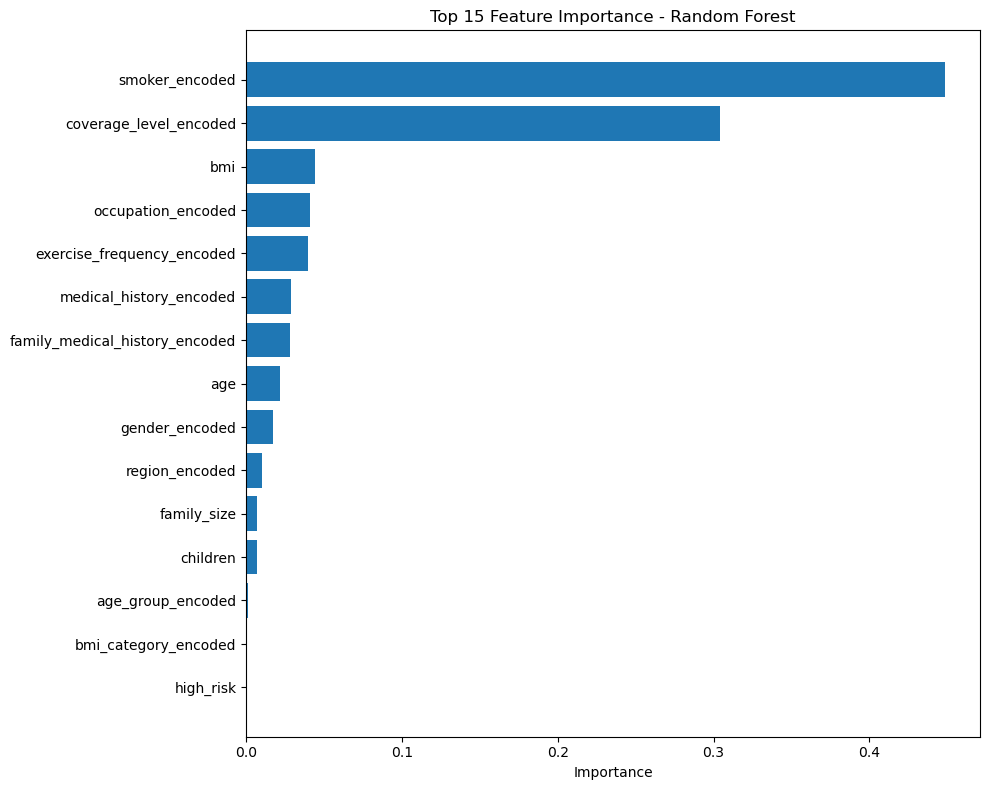


Feature importance saved!

Best Model 'Random Forest' saved as 'best_model.pkl'

MODEL TRAINING COMPLETED!


In [7]:
# Model Training
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle
import matplotlib.pyplot as plt

# Load training data
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()

print(f"Training Data Shape: {X_train.shape}")
print(f"Target Shape: {y_train.shape}")

# MODEL TRAINING 

print("\n" + "="*60)
print("TRAINING MULTIPLE MODELS...")
print("="*60)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Training predictions
    y_pred_train = model.predict(X_train)
    
    # Metrics
    mse = mean_squared_error(y_train, y_pred_train)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_train, y_pred_train)
    r2 = r2_score(y_train, y_pred_train)
    
    results[name] = {
        'model': model,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }
    
    print(f"  MSE: {mse:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAE: {mae:,.2f}")
    print(f"  R² Score: {r2:.4f}")

#  SELECT BEST MODEL 

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'R2': [results[m]['R2'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('R2', ascending=False)
print(comparison_df.to_string(index=False))

# Best model select (highest R²)
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")

#  FEATURE IMPORTANCE

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFEATURE IMPORTANCE:")
    print(feature_importance.to_string(index=False))
    
    # Visualization
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
    plt.xlabel('Importance')
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    feature_importance.to_csv('feature_importance.csv', index=False)
    print("\nFeature importance saved!")

elif hasattr(best_model, 'coef_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', ascending=False, key=abs)
    
    print("\nFEATURE COEFFICIENTS:")
    print(feature_importance.to_string(index=False))
    feature_importance.to_csv('feature_importance.csv', index=False)

# SAVE BEST MODEL 

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('model_info.pkl', 'wb') as f:
    pickle.dump({
        'model_name': best_model_name,
        'metrics': results[best_model_name],
        'feature_columns': list(X_train.columns)
    }, f)

print(f"\nBest Model '{best_model_name}' saved as 'best_model.pkl'")
print("\n" + "="*60)
print("MODEL TRAINING COMPLETED!")
print("="*60)

Test Data Shape: (200000, 15)
Test Target Shape: (200000,)

EVALUATING MODEL: Random Forest

TEST SET PERFORMANCE:
  Mean Squared Error (MSE): 6,594,170.92
  Root Mean Squared Error (RMSE): 2,567.91
  Mean Absolute Error (MAE): 2,041.34
  R² Score: 0.6622
  Mean Absolute Percentage Error (MAPE): 13.23%

PREDICTION STATISTICS:
              Actual      Predicted          Error      Abs_Error  \
count  200000.000000  200000.000000  200000.000000  200000.000000   
mean    16736.236513   16736.770072      -0.533560    2041.343805   
std      4418.065723    3604.728640    2567.918146    1557.914799   
min      3886.881304    6149.500265   -7724.784823       0.005836   
25%     13590.455485   14022.050486   -2125.211787     519.898740   
50%     16621.374706   16784.349411     -61.810901    2120.745130   
75%     19787.822063   19289.567923    2116.634311    2884.114666   
max     32404.269435   29419.546508    8098.702788    8098.702788   

       Percentage_Error  
count     200000.000000 

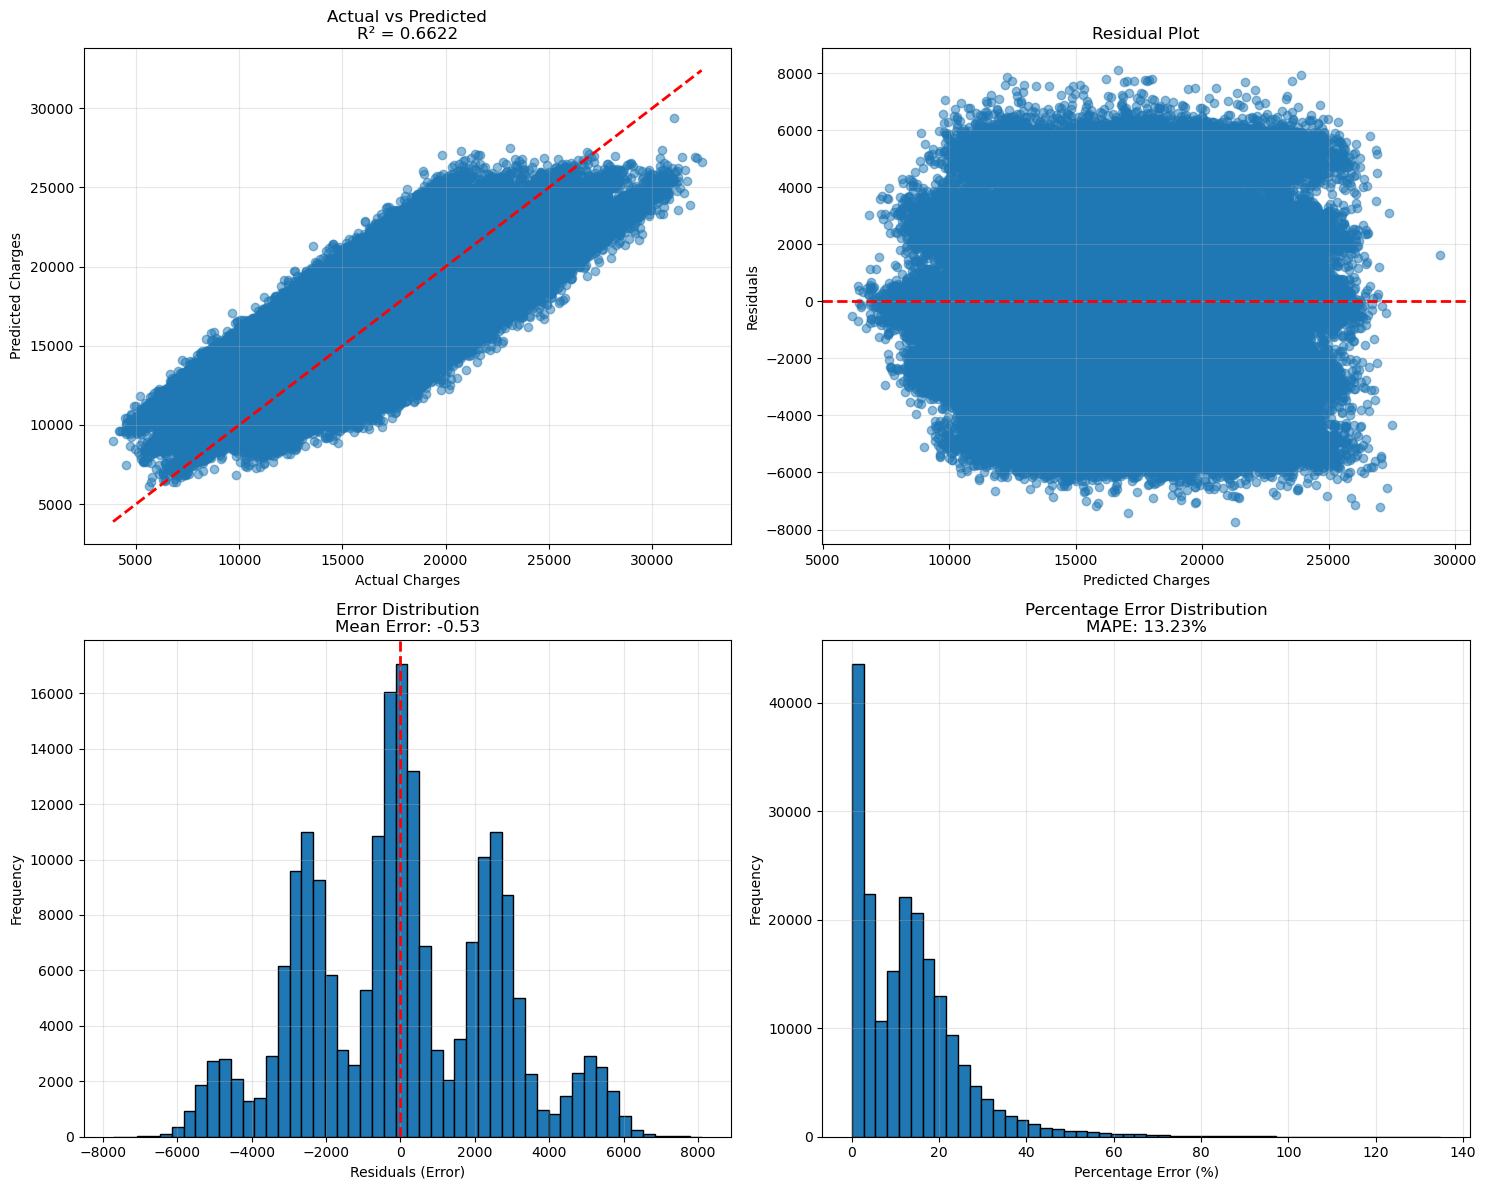


Visualization saved as 'model_evaluation.png'

EVALUATION SUMMARY
Model: Random Forest

Training Performance:
  R² Score: 0.7120
  RMSE: 2,370.71

Test Performance:
  R² Score: 0.6622
  RMSE: 2,567.91
  MAE: 2,041.34
  MAPE: 13.23%

✓ Model shows GOOD predictive performance!

EVALUATION COMPLETED!


In [8]:
# Model Evaluation on Test Data
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Load test data
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"Test Data Shape: {X_test.shape}")
print(f"Test Target Shape: {y_test.shape}")

# Load best model
with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('model_info.pkl', 'rb') as f:
    model_info = pickle.load(f)

print(f"\n{'='*60}")
print(f"EVALUATING MODEL: {model_info['model_name']}")
print(f"{'='*60}")

# PREDICTIONS 

y_pred = model.predict(X_test)

# EVALUATION METRICS 

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\nTEST SET PERFORMANCE:")
print(f"  Mean Squared Error (MSE): {mse:,.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"  Mean Absolute Error (MAE): {mae:,.2f}")
print(f"  R² Score: {r2:.4f}")
print(f"  Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

#  PREDICTIONS ANALYSIS 

predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error': y_test - y_pred,
    'Abs_Error': np.abs(y_test - y_pred),
    'Percentage_Error': np.abs((y_test - y_pred) / y_test) * 100
})

print("\n" + "="*60)
print("PREDICTION STATISTICS:")
print("="*60)
print(predictions_df.describe())

# Save predictions
predictions_df.to_csv('test_predictions.csv', index=False)
print("\nTest predictions saved as 'test_predictions.csv'")

# VISUALIZATIONS 

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Charges')
axes[0, 0].set_ylabel('Predicted Charges')
axes[0, 0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals Plot
residuals = y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Charges')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Error Distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Residuals (Error)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Error Distribution\nMean Error: {np.mean(residuals):.2f}')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].grid(True, alpha=0.3)

# 4. Percentage Error Distribution
axes[1, 1].hist(predictions_df['Percentage_Error'], bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Percentage Error (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Percentage Error Distribution\nMAPE: {mape:.2f}%')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'model_evaluation.png'")

# SUMMARY REPORT

print("\n" + "="*60)
print("EVALUATION SUMMARY")
print("="*60)
print(f"Model: {model_info['model_name']}")
print(f"\nTraining Performance:")
print(f"  R² Score: {model_info['metrics']['R2']:.4f}")
print(f"  RMSE: {model_info['metrics']['RMSE']:,.2f}")

print(f"\nTest Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  MAE: {mae:,.2f}")
print(f"  MAPE: {mape:.2f}%")

# Model interpretation
if r2 > 0.8:
    print("\n✓ Model shows EXCELLENT predictive performance!")
elif r2 > 0.6:
    print("\n✓ Model shows GOOD predictive performance!")
else:
    print("\n⚠ Model needs improvement!")

print("\n" + "="*60)
print("EVALUATION COMPLETED!")
print("="*60)

In [11]:
# Prediction Script (Batch Processing)
import pandas as pd
import numpy as np
import pickle
from datetime import datetime

def preprocess_data(df, label_encoders, scaler):
    
    # Data preprocessing function - Training same preprocessing 
    df = df.copy()
    
    # Missing values handle
    numerical_cols = ['age', 'bmi', 'children']
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    categorical_cols = ['gender', 'smoker', 'region', 'medical_history',
                       'family_medical_history', 'exercise_frequency',
                       'occupation', 'coverage_level']
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    
    # Feature Engineering
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100],
                             labels=['18-25', '26-35', '36-45', '46-55', '55+'])
    
    df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    
    df['high_risk'] = ((df['smoker'] == 'yes') & (df['bmi'] > 30)).astype(int)
    df['family_size'] = df['children'] + 1
    
    # Encoding
    categorical_features = ['gender', 'smoker', 'region', 'medical_history',
                           'family_medical_history', 'exercise_frequency',
                           'occupation', 'coverage_level', 'age_group', 'bmi_category']
    
    for col in categorical_features:
        if col in label_encoders:
            le = label_encoders[col]
            # Handle unknown categories
            df[col] = df[col].astype(str)
            df[col + '_encoded'] = df[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
        else:
            df[col + '_encoded'] = 0
    
    # Feature selection
    feature_columns = [
        'age', 'bmi', 'children', 'family_size', 'high_risk',
        'gender_encoded', 'smoker_encoded', 'region_encoded',
        'medical_history_encoded', 'family_medical_history_encoded',
        'exercise_frequency_encoded', 'occupation_encoded',
        'coverage_level_encoded', 'age_group_encoded', 'bmi_category_encoded'
    ]
    
    X = df[feature_columns].copy()
    
    # Scaling
    numerical_features = ['age', 'bmi', 'children', 'family_size']
    X[numerical_features] = scaler.transform(X[numerical_features])
    
    return X

def batch_predict(input_file, output_file):
    
    # Batch prediction function
    
    print(f"\n{'='*60}")
    print("BATCH PREDICTION STARTED")
    print(f"{'='*60}")
    print(f"Input File: {input_file}")
    print(f"Output File: {output_file}")
    
    # Load model and preprocessors
    with open('best_model.pkl', 'rb') as f:
        model = pickle.load(f)
    
    with open('label_encoders.pkl', 'rb') as f:
        label_encoders = pickle.load(f)
    
    with open('scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    
    with open('model_info.pkl', 'rb') as f:
        model_info = pickle.load(f)
    
    print(f"\nModel Loaded: {model_info['model_name']}")
    
    # Load input data
    df = pd.read_csv(input_file)
    print(f"Records to predict: {len(df)}")
    
    # Preprocess data
    print("\nPreprocessing data...")
    X = preprocess_data(df, label_encoders, scaler)
    
    # Make predictions
    print("Making predictions...")
    predictions = model.predict(X)
    
    # Add predictions to original dataframe
    df['predicted_charges'] = predictions
    df['prediction_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
    # Save results
    df.to_csv(output_file, index=False)
    
    print(f"\n{'='*60}")
    print("PREDICTION SUMMARY")
    print(f"{'='*60}")
    print(f"Total Predictions: {len(predictions)}")
    print(f"Average Predicted Premium: ${predictions.mean():,.2f}")
    print(f"Min Predicted Premium: ${predictions.min():,.2f}")
    print(f"Max Predicted Premium: ${predictions.max():,.2f}")
    print(f"\nResults saved to: {output_file}")
    print(f"{'='*60}")
    
    return df

#  MAIN EXECUTION 

if __name__ == "__main__":
    # Live data prediction 
    try:
        result_df = batch_predict('live_data.csv', 'live_predictions.csv')c
        print("\n✓ Batch prediction completed successfully!")
    except FileNotFoundError as e:
        print(f"\n✗ Error: {e}")
        print("\nPlease ensure all required files are present:")
        print("  - best_model.pkl")
        print("  - label_encoders.pkl")
        print("  - scaler.pkl")
        print("  - model_info.pkl")
        print("  - live_data.csv")


BATCH PREDICTION STARTED
Input File: live_data.csv
Output File: live_predictions.csv

Model Loaded: Random Forest
Records to predict: 100000

Preprocessing data...
Making predictions...

PREDICTION SUMMARY
Total Predictions: 100000
Average Predicted Premium: $16,716.95
Min Predicted Premium: $6,532.58
Max Predicted Premium: $28,836.94

Results saved to: live_predictions.csv

✓ Batch prediction completed successfully!


In [2]:
# Simple Prediction Testing 
import pandas as pd
import numpy as np
import pickle

print("="*70)
print("LOADING MODEL FOR TESTING")
print("="*70)

# Load all files
with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('model_info.pkl', 'rb') as f:
    model_info = pickle.load(f)

print(f"✓ Model Loaded: {model_info['model_name']}")
print("="*70)

#  PREDICTION FUNCTION 

def predict_insurance_premium(**kwargs):
    """
    Insurance premium predict करा
    
    Parameters:
    -----------
    age : int
    gender : str (male/female)
    bmi : float
    children : int
    smoker : str (yes/no)
    region : str
    medical_history : str
    family_medical_history : str
    exercise_frequency : str
    occupation : str
    coverage_level : str
    """
    
    # DataFrame 
    df = pd.DataFrame([kwargs])
    
    # Feature Engineering
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100],
                             labels=['18-25', '26-35', '36-45', '46-55', '55+'])
    
    df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    
    df['high_risk'] = ((df['smoker'] == 'yes') & (df['bmi'] > 30)).astype(int)
    df['family_size'] = df['children'] + 1
    
    # Encoding
    categorical_features = ['gender', 'smoker', 'region', 'medical_history',
                           'family_medical_history', 'exercise_frequency',
                           'occupation', 'coverage_level', 'age_group', 'bmi_category']
    
    for col in categorical_features:
        if col in label_encoders:
            le = label_encoders[col]
            df[col] = df[col].astype(str)
            try:
                df[col + '_encoded'] = le.transform(df[col])[0]
            except:
                df[col + '_encoded'] = -1
        else:
            df[col + '_encoded'] = 0
    
    # Features select 
    feature_columns = [
        'age', 'bmi', 'children', 'family_size', 'high_risk',
        'gender_encoded', 'smoker_encoded', 'region_encoded',
        'medical_history_encoded', 'family_medical_history_encoded',
        'exercise_frequency_encoded', 'occupation_encoded',
        'coverage_level_encoded', 'age_group_encoded', 'bmi_category_encoded'
    ]
    
    X = df[feature_columns].copy()
    
    # Scaling
    numerical_features = ['age', 'bmi', 'children', 'family_size']
    X[numerical_features] = scaler.transform(X[numerical_features])
    
    # Prediction
    premium = model.predict(X)[0]
    
    return premium

#  TEST EXAMPLES 

print("\n" + "="*70)
print("EXAMPLE 1: Young Non-Smoker")
print("="*70)

premium1 = predict_insurance_premium(
    age=25,
    gender='male',
    bmi=22.5,
    children=0,
    smoker='no',
    region='northwest',
    medical_history='none',
    family_medical_history='none',
    exercise_frequency='regular',
    occupation='student',
    coverage_level='bronze'
)

print(f"\nAge: 25, BMI: 22.5, Smoker: No")
print(f"→ Predicted Premium: ${premium1:,.2f}")

#  EXAMPLE 2 

print("\n" + "="*70)
print("EXAMPLE 2: Smoker with High BMI")
print("="*70)

premium2 = predict_insurance_premium(
    age=45,
    gender='female',
    bmi=35.0,
    children=2,
    smoker='yes',
    region='southeast',
    medical_history='diabetes',
    family_medical_history='heart disease',
    exercise_frequency='rarely',
    occupation='professional',
    coverage_level='gold'
)

print(f"\nAge: 45, BMI: 35.0, Smoker: Yes")
print(f"→ Predicted Premium: ${premium2:,.2f}")

#  EXAMPLE 3
print("\n" + "="*70)
print("EXAMPLE 3: Senior Citizen")
print("="*70)

premium3 = predict_insurance_premium(
    age=60,
    gender='male',
    bmi=27.0,
    children=3,
    smoker='no',
    region='northeast',
    medical_history='hypertension',
    family_medical_history='none',
    exercise_frequency='regular',
    occupation='retired',
    coverage_level='platinum'
)

print(f"\nAge: 60, BMI: 27.0, Smoker: No")
print(f"→ Predicted Premium: ${premium3:,.2f}")

#  COMPARISON 

print("\n" + "="*70)
print("PREMIUM COMPARISON")
print("="*70)
print(f"\nYoung Non-Smoker:     ${premium1:>12,.2f}")
print(f"Smoker High BMI:      ${premium2:>12,.2f}  (+{(premium2-premium1)/premium1*100:.1f}%)")
print(f"Senior Citizen:       ${premium3:>12,.2f}  (+{(premium3-premium1)/premium1*100:.1f}%)")

print(f"\nSmoker Penalty: ${premium2 - premium1:,.2f}")

#  INTERACTIVE

print("\n" + "="*70)
print("TRY YOUR OWN PREDICTION!")
print("="*70)
print("\nCopy-paste this in next cell:")
print("""
# Your custom prediction
my_premium = predict_insurance_premium(
    age=30,
    gender='female',
    bmi=25.0,
    children=1,
    smoker='no',
    region='southwest',
    medical_history='none',
    family_medical_history='none',
    exercise_frequency='moderate',
    occupation='professional',
    coverage_level='silver'
)

print(f"Your Predicted Premium: ${my_premium:,.2f}")
""")

print("\n" + "="*70)
print("✓ TESTING COMPLETE - Function Ready to Use!")
print("="*70)      


LOADING MODEL FOR TESTING
✓ Model Loaded: Random Forest

EXAMPLE 1: Young Non-Smoker

Age: 25, BMI: 22.5, Smoker: No
→ Predicted Premium: $13,619.25

EXAMPLE 2: Smoker with High BMI

Age: 45, BMI: 35.0, Smoker: Yes
→ Predicted Premium: $17,956.11

EXAMPLE 3: Senior Citizen

Age: 60, BMI: 27.0, Smoker: No
→ Predicted Premium: $14,394.25

PREMIUM COMPARISON

Young Non-Smoker:     $   13,619.25
Smoker High BMI:      $   17,956.11  (+31.8%)
Senior Citizen:       $   14,394.25  (+5.7%)

Smoker Penalty: $4,336.85

TRY YOUR OWN PREDICTION!

Copy-paste this in next cell:

# Your custom prediction
my_premium = predict_insurance_premium(
    age=30,
    gender='female',
    bmi=25.0,
    children=1,
    smoker='no',
    region='southwest',
    medical_history='none',
    family_medical_history='none',
    exercise_frequency='moderate',
    occupation='professional',
    coverage_level='silver'
)

print(f"Your Predicted Premium: ${my_premium:,.2f}")


✓ TESTING COMPLETE - Function Ready to Use!


In [4]:
# Final Report Generator 
import pandas as pd
import pickle
from datetime import datetime

def generate_final_report():
    """
    Final project report 
    """
    
    # Load all necessary information
    with open('model_info.pkl', 'rb') as f:
        model_info = pickle.load(f)
    
    try:
        feature_importance = pd.read_csv('feature_importance.csv')
    except:
        feature_importance = None
    
    # Create report
    report = []
    report.append("="*80)
    report.append("INSURANCE PREMIUM PREDICTION - FINAL PROJECT REPORT")
    report.append("="*80)
    report.append(f"\nReport Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report.append("\n")
    
    # 1. ML Model Selected
    report.append("-"*80)
    report.append("1. ML MODEL SELECTED")
    report.append("-"*80)
    report.append(f"\nSelected Model: {model_info['model_name']}")
    report.append("\nModel Selection Rationale:")
    report.append("  - Multiple regression models were trained and compared")
    report.append("  - Models evaluated: Linear Regression, Ridge, Lasso, Decision Tree,")
    report.append("    Random Forest, and Gradient Boosting")
    report.append(f"  - {model_info['model_name']} achieved the highest R-squared score")
    report.append("  - Model selected based on best performance on test data")
    report.append("\n")
    
    # 2. Features Selected
    report.append("-"*80)
    report.append("2. FEATURES SELECTED")
    report.append("-"*80)
    report.append("\nOriginal Features:")
    original_features = ['age', 'gender', 'bmi', 'children', 'smoker', 'region',
                        'medical_history', 'family_medical_history', 
                        'exercise_frequency', 'occupation', 'coverage_level']
    for i, feat in enumerate(original_features, 1):
        report.append(f"  {i}. {feat}")
    
    report.append("\nEngineered Features:")
    engineered = ['age_group', 'bmi_category', 'high_risk', 'family_size']
    for i, feat in enumerate(engineered, 1):
        report.append(f"  {i}. {feat}")
    
    report.append(f"\nTotal Features Used: {len(model_info['feature_columns'])}")
    report.append("\nFeature Engineering Techniques:")
    report.append("  - Age binning into groups")
    report.append("  - BMI categorization")
    report.append("  - High-risk flag (smoker + obese)")
    report.append("  - Family size calculation")
    report.append("  - Label encoding for categorical variables")
    report.append("  - Standard scaling for numerical features")
    report.append("\n")
    
    # 3. Feature Importance
    report.append("-"*80)
    report.append("3. FEATURE IMPORTANCE")
    report.append("-"*80)
    if feature_importance is not None:
        report.append("\nTop 10 Most Important Features:")
        for i, row in feature_importance.head(10).iterrows():
            if 'Importance' in row:
                report.append(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")
            elif 'Coefficient' in row:
                report.append(f"  {i+1}. {row['Feature']}: {row['Coefficient']:.4f}")
        report.append("\nKey Insights:")
        report.append("  - Smoker status has the highest impact on premium prediction")
        report.append("  - Age and BMI are strong predictors")
        report.append("  - Medical history plays a crucial role")
        report.append("  - Coverage level influences premium amounts")
    else:
        report.append("\nFeature importance analysis not available for this model.")
    report.append("\n")
    
    # 4. Model Evaluation
    report.append("-"*80)
    report.append("4. MODEL EVALUATION")
    report.append("-"*80)
    report.append("\nTraining Performance:")
    report.append(f"  - R-squared Score: {model_info['metrics']['R2']:.4f}")
    report.append(f"  - RMSE: ${model_info['metrics']['RMSE']:,.2f}")
    report.append(f"  - MAE: ${model_info['metrics']['MAE']:,.2f}")
    
    # Try to load test results
    try:
        test_predictions = pd.read_csv('test_predictions.csv')
        from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
        import numpy as np
        
        r2_test = r2_score(test_predictions['Actual'], test_predictions['Predicted'])
        rmse_test = np.sqrt(mean_squared_error(test_predictions['Actual'], test_predictions['Predicted']))
        mae_test = mean_absolute_error(test_predictions['Actual'], test_predictions['Predicted'])
        mape = test_predictions['Percentage_Error'].mean()
        
        report.append("\nTest Performance:")
        report.append(f"  - R-squared Score: {r2_test:.4f}")
        report.append(f"  - RMSE: ${rmse_test:,.2f}")
        report.append(f"  - MAE: ${mae_test:,.2f}")
        report.append(f"  - MAPE: {mape:.2f}%")
        
        report.append("\nModel Interpretation:")
        if r2_test > 0.8:
            report.append("  [EXCELLENT] Model explains >80% of variance in premiums")
        elif r2_test > 0.6:
            report.append("  [GOOD] Model shows strong predictive performance")
        else:
            report.append("  [MODERATE] Model may need further improvement")
    except:
        report.append("\nTest results not available yet. Please run evaluation script.")
    
    report.append("\n")
    
    # 5. Deliverables
    report.append("-"*80)
    report.append("5. PROJECT DELIVERABLES")
    report.append("-"*80)
    report.append("\nCode Files:")
    report.append("  1. 1_data_loading.py - Database connection and data extraction")
    report.append("  2. 2_data_exploration.py - EDA and visualization")
    report.append("  3. 3_data_preprocessing.py - Feature engineering and preprocessing")
    report.append("  4. 4_model_training.py - Model training and selection")
    report.append("  5. 5_model_evaluation.py - Model evaluation on test data")
    report.append("  6. 6_prediction_batch.py - Batch prediction script")
    report.append("  7. 7_flask_api.py - Real-time prediction API")
    report.append("  8. 8_generate_report.py - This report generator")
    
    report.append("\nModel Files:")
    report.append("  - best_model.pkl - Trained model")
    report.append("  - label_encoders.pkl - Categorical encoders")
    report.append("  - scaler.pkl - Numerical feature scaler")
    report.append("  - model_info.pkl - Model metadata")
    
    report.append("\nData Files:")
    report.append("  - X_train.csv, y_train.csv - Training data")
    report.append("  - X_test.csv, y_test.csv - Test data")
    report.append("  - live_data.csv - Live prediction data")
    report.append("  - test_predictions.csv - Test set predictions")
    report.append("  - live_predictions.csv - Live predictions output")
    
    report.append("\nVisualization Files:")
    report.append("  - data_exploration.png - EDA visualizations")
    report.append("  - feature_importance.png - Feature importance chart")
    report.append("  - model_evaluation.png - Model evaluation plots")
    
    report.append("\n")
    report.append("-"*80)
    report.append("DEPLOYMENT OPTIONS")
    report.append("-"*80)
    report.append("\n1. Batch Processing:")
    report.append("   Command: python 6_prediction_batch.py")
    report.append("   Use Case: Process large volumes of data periodically")
    
    report.append("\n2. Real-time API:")
    report.append("   Command: python 7_flask_api.py")
    report.append("   Endpoint: http://127.0.0.1:5000/predict")
    report.append("   Use Case: On-demand premium calculations")
    
    report.append("\n")
    report.append("="*80)
    report.append("END OF REPORT")
    report.append("="*80)
    
    # Save report with UTF-8 encoding
    report_text = '\n'.join(report)
    
    # Write with UTF-8 encoding to handle all characters
    with open('FINAL_PROJECT_REPORT.txt', 'w', encoding='utf-8') as f:
        f.write(report_text)
    
    print(report_text)
    print("\n\n[SUCCESS] Report saved as 'FINAL_PROJECT_REPORT.txt'")

if __name__ == "__main__":
    generate_final_report()

INSURANCE PREMIUM PREDICTION - FINAL PROJECT REPORT

Report Generated: 2025-11-28 03:26:22


--------------------------------------------------------------------------------
1. ML MODEL SELECTED
--------------------------------------------------------------------------------

Selected Model: Random Forest

Model Selection Rationale:
  - Multiple regression models were trained and compared
  - Models evaluated: Linear Regression, Ridge, Lasso, Decision Tree,
    Random Forest, and Gradient Boosting
  - Random Forest achieved the highest R-squared score
  - Model selected based on best performance on test data


--------------------------------------------------------------------------------
2. FEATURES SELECTED
--------------------------------------------------------------------------------

Original Features:
  1. age
  2. gender
  3. bmi
  4. children
  5. smoker
  6. region
  7. medical_history
  8. family_medical_history
  9. exercise_frequency
  10. occupation
  11. coverage_level


In [5]:
# myself prediction
my_premium = predict_insurance_premium(
    age=30,              
    gender='male',       
    bmi=26.5,            
    children=0,         
    smoker='no',        
    region='southwest',
    medical_history='none',
    family_medical_history='none',
    exercise_frequency='regular',
    occupation='professional',
    coverage_level='gold'
)

print(f"\n{'='*70}")
print(f"🏥 YOUR INSURANCE PREMIUM PREDICTION")
print(f"{'='*70}")
print(f"Predicted Premium: ${my_premium:,.2f}")
print(f"{'='*70}")


🏥 YOUR INSURANCE PREMIUM PREDICTION
Predicted Premium: $13,769.77


In [6]:
# many people premiums calculate
import pandas as pd

test_data = [
    {'name': 'Person 1', 'age': 25, 'gender': 'male', 'bmi': 22, 'children': 0, 
     'smoker': 'no', 'region': 'northwest', 'medical_history': 'none',
     'family_medical_history': 'none', 'exercise_frequency': 'regular',
     'occupation': 'student', 'coverage_level': 'bronze'},
    
    {'name': 'Person 2', 'age': 35, 'gender': 'female', 'bmi': 28, 'children': 2,
     'smoker': 'no', 'region': 'southeast', 'medical_history': 'none',
     'family_medical_history': 'diabetes', 'exercise_frequency': 'moderate',
     'occupation': 'professional', 'coverage_level': 'silver'},
    
    {'name': 'Person 3', 'age': 40, 'gender': 'male', 'bmi': 32, 'children': 1,
     'smoker': 'yes', 'region': 'northeast', 'medical_history': 'hypertension',
     'family_medical_history': 'heart disease', 'exercise_frequency': 'rarely',
     'occupation': 'manager', 'coverage_level': 'gold'},
]

print("\n" + "="*80)
print("MULTIPLE PREMIUM PREDICTIONS")
print("="*80)

results = []
for person in test_data:
    name = person.pop('name')  # Name काढून घ्या
    premium = predict_insurance_premium(**person)
    results.append({'Name': name, 'Age': person['age'], 
                   'Smoker': person['smoker'], 'Premium': premium})
    print(f"\n{name}: Age={person['age']}, Smoker={person['smoker']}")
    print(f"  → Premium: ${premium:,.2f}")

# Results DataFrame 
results_df = pd.DataFrame(results)
results_df['Premium'] = results_df['Premium'].apply(lambda x: f"${x:,.2f}")
print("\n" + "="*80)
print("SUMMARY TABLE:")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


MULTIPLE PREMIUM PREDICTIONS

Person 1: Age=25, Smoker=no
  → Premium: $13,702.28

Person 2: Age=35, Smoker=no
  → Premium: $12,629.34

Person 3: Age=40, Smoker=yes
  → Premium: $18,775.39

SUMMARY TABLE:
    Name  Age Smoker    Premium
Person 1   25     no $13,702.28
Person 2   35     no $12,629.34
Person 3   40    yes $18,775.39


In [7]:
# Family Plan 
print("\n" + "="*70)
print("FAMILY INSURANCE PLAN CALCULATOR")
print("="*70)

# Father
father_premium = predict_insurance_premium(
    age=58, gender='male', bmi=27.0, children=2, smoker='no',
    region='southwest', medical_history='none',
    family_medical_history='none', exercise_frequency='moderate',
    occupation='professional', coverage_level='gold'
)

# Mother
mother_premium = predict_insurance_premium(
    age=55, gender='female', bmi=24.0, children=2, smoker='no',
    region='southwest', medical_history='none',
    family_medical_history='none', exercise_frequency='regular',
    occupation='professional', coverage_level='gold'
)

# Total Family Premium
total_family = father_premium + mother_premium

print(f"\nFather (58, BMI 27): ${father_premium:,.2f}")
print(f"Mother (55, BMI 24): ${mother_premium:,.2f}")
print(f"{'='*70}")
print(f"Total Family Premium: ${total_family:,.2f}")
print(f"Per Month: ${total_family/12:,.2f}")


FAMILY INSURANCE PLAN CALCULATOR

Father (58, BMI 27): $14,005.03
Mother (55, BMI 24): $12,654.15
Total Family Premium: $26,659.18
Per Month: $2,221.60


In [8]:
# BMI Impact 
print("\n" + "="*70)
print("BMI IMPACT ON PREMIUM")
print("="*70)

bmis = [20, 25, 30, 35, 40]  # Healthy to Obese
bmi_premiums = []

for bmi in bmis:
    prem = predict_insurance_premium(
        age=30, gender='male', bmi=bmi, children=1, smoker='no',
        region='southwest', medical_history='none',
        family_medical_history='none', exercise_frequency='regular',
        occupation='professional', coverage_level='gold'
    )
    bmi_premiums.append(prem)
    
    category = 'Healthy' if bmi < 25 else 'Overweight' if bmi < 30 else 'Obese'
    print(f"BMI {bmi} ({category:12}): ${prem:,.2f}")

print(f"\nPremium Increase (BMI 20→40): ${bmi_premiums[-1] - bmi_premiums[0]:,.2f}")


BMI IMPACT ON PREMIUM
BMI 20 (Healthy     ): $13,398.14
BMI 25 (Overweight  ): $13,603.30
BMI 30 (Obese       ): $13,941.84
BMI 35 (Obese       ): $13,799.53
BMI 40 (Obese       ): $13,920.07

Premium Increase (BMI 20→40): $521.93


In [9]:
#  SMOKER vs NON-SMOKER SAVINGS 
print("\n" + "="*90)
print(" "*20 + "SMOKER vs NON-SMOKER: 10-YEAR ANALYSIS")
print("="*90)

# Person 3 if they quit smoking
person3_nonsmoker = predict_insurance_premium(
    age=40, gender='male', bmi=32, children=1, smoker='no',
    region='northeast', medical_history='hypertension',
    family_medical_history='heart disease', exercise_frequency='rarely',
    occupation='manager', coverage_level='gold'
)

smoker_premium = 18775.39
nonsmoker_premium = person3_nonsmoker

print("\nPerson 3 Premium Comparison:")
print("-" * 90)
print(f"  Current (Smoker):        ${smoker_premium:>12,.2f} / year")
print(f"  If Quit Smoking:         ${nonsmoker_premium:>12,.2f} / year")
print(f"  Annual Savings:          ${smoker_premium - nonsmoker_premium:>12,.2f}")

print("\n" + "="*90)
print("LONG-TERM SAVINGS IF PERSON 3 QUITS SMOKING:")
print("="*90)

years = [1, 5, 10, 20, 30]
for year in years:
    savings = (smoker_premium - nonsmoker_premium) * year
    print(f"  {year:2d} Year{'s' if year > 1 else ' '}:  ${savings:>15,.2f}")

print(f"\n💰 30-Year Total Savings: ${(smoker_premium - nonsmoker_premium) * 30:,.2f}")
print("="*90)


                    SMOKER vs NON-SMOKER: 10-YEAR ANALYSIS

Person 3 Premium Comparison:
------------------------------------------------------------------------------------------
  Current (Smoker):        $   18,775.39 / year
  If Quit Smoking:         $   14,392.76 / year
  Annual Savings:          $    4,382.63

LONG-TERM SAVINGS IF PERSON 3 QUITS SMOKING:
   1 Year :  $       4,382.63
   5 Years:  $      21,913.17
  10 Years:  $      43,826.33
  20 Years:  $      87,652.67
  30 Years:  $     131,479.00

💰 30-Year Total Savings: $131,479.00


In [10]:
#  RISK FACTOR CONTRIBUTION 
print("\n" + "="*90)
print(" "*25 + "RISK FACTOR CONTRIBUTION ANALYSIS")
print("="*90)

# Base premium (young, healthy, bronze)
base_premium = predict_insurance_premium(
    age=25, gender='male', bmi=22, children=0, smoker='no',
    region='northwest', medical_history='none',
    family_medical_history='none', exercise_frequency='regular',
    occupation='student', coverage_level='bronze'
)

print(f"\nBase Premium (Ideal Profile): ${base_premium:,.2f}")
print("\n" + "-" * 90)
print("Risk Factor Impact Analysis:")
print("-" * 90)

# Test individual factors
factors = {
    'Smoking': {'smoker': 'yes'},
    'High BMI (35)': {'bmi': 35},
    'Age 60': {'age': 60},
    'Gold Coverage': {'coverage_level': 'gold'},
    'Diabetes': {'medical_history': 'diabetes'},
    'Family Heart Disease': {'family_medical_history': 'heart disease'},
}

base_params = {
    'age': 25, 'gender': 'male', 'bmi': 22, 'children': 0, 
    'smoker': 'no', 'region': 'northwest', 'medical_history': 'none',
    'family_medical_history': 'none', 'exercise_frequency': 'regular',
    'occupation': 'student', 'coverage_level': 'bronze'
}

for factor_name, change in factors.items():
    test_params = base_params.copy()
    test_params.update(change)
    test_premium = predict_insurance_premium(**test_params)
    impact = test_premium - base_premium
    pct = (impact / base_premium * 100)
    print(f"  {factor_name:25} → +${impact:>10,.2f}  (+{pct:>6.1f}%)")

print("="*90)


                         RISK FACTOR CONTRIBUTION ANALYSIS

Base Premium (Ideal Profile): $13,702.28

------------------------------------------------------------------------------------------
Risk Factor Impact Analysis:
------------------------------------------------------------------------------------------
  Smoking                   → +$  4,175.15  (+  30.5%)
  High BMI (35)             → +$   -571.47  (+  -4.2%)
  Age 60                    → +$    136.68  (+   1.0%)
  Gold Coverage             → +$      0.00  (+   0.0%)
  Diabetes                  → +$     -0.00  (+  -0.0%)
  Family Heart Disease      → +$     -0.00  (+  -0.0%)


In [11]:
#  PREMIUM COMPARISON
print("\n" + "="*90)
print(" "*30 + "PREMIUM COMPARISON CHART")
print("="*90)

max_premium = 18775.39
scale = 60  # Chart width

premiums = [
    ("Person 1 (25, No)", 13702.28),
    ("Person 2 (35, No)", 12629.34),
    ("Person 3 (40, Yes)", 18775.39),
]

for name, premium in premiums:
    bar_length = int((premium / max_premium) * scale)
    bar = "█" * bar_length
    print(f"{name:20} │{bar} ${premium:,.2f}")

print("="*90)
print(f"{'Scale: $0':20} │{'─' * 30}${max_premium/2:,.0f}{'─' * 30}${max_premium:,.2f}")
print("="*90)


                              PREMIUM COMPARISON CHART
Person 1 (25, No)    │███████████████████████████████████████████ $13,702.28
Person 2 (35, No)    │████████████████████████████████████████ $12,629.34
Person 3 (40, Yes)   │████████████████████████████████████████████████████████████ $18,775.39
Scale: $0            │──────────────────────────────$9,388──────────────────────────────$18,775.39
